### 데이터 가공

## 1. 데이터를 읽어들여 bikes데이터 프레임 만들기

In [1]:
# folium 모듈 설치하기
!pip install folium


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 모듈 import하기 / pandas, seaborn, matplotlib.pyplot, folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import seaborn as sns

In [47]:
# 6개의 파일로 나누어진 bike_rent파일을 하나씩 읽어오기

bikes_temp = {}         #빈 데이터 프레임

# 6개의 파일을 bikes_temp[0]~[5]까지 읽어 들인다
for i in range(6):
    bikes_temp[i] = pd.read_csv(f'data/bike_rent_{i+1}.csv', encoding = 'cp949',
    parse_dates=['대여일시'])

In [48]:
#각각 파일 확인
bikes_temp

{0:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 1:    

In [49]:
bikes_temp[5].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315722 entries, 0 to 315721
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   자전거번호     315722 non-null  object        
 1   대여일시      315722 non-null  datetime64[ns]
 2   대여 대여소번호  315722 non-null  int64         
 3   대여 대여소명   315722 non-null  object        
 4   이용시간      315722 non-null  int64         
 5   이용거리      315722 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 14.5+ MB


In [50]:
#6개의 파일을 최종 bikes파일로 데이터 프레임 만들어 bikes에 저장하기
#ignore_index 기존 인덱스를 무시하고 다시 순서를 0부터 정한다.
bikes = pd.concat(bikes_temp, ignore_index= True)

In [51]:
#최종 행을 확인해서 제대로 연결 되었는지 확인 2215631행
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


## 2.데이터 프레임 관찰

In [52]:
# bike데이터 프레임의 기본정보 확인하기
bikes.info()

# 원래는 null, nan 개수가 나오지만 100만개 이상인 데이터는 안세줌

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     object        
 1   대여일시      datetime64[ns]
 2   대여 대여소번호  int64         
 3   대여 대여소명   object        
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 101.4+ MB


In [53]:
# 프레임의 전체 구조 (행, 열) 확인하기
bikes.shape

(2215632, 6)

In [54]:
# 프레임의 행 확인하기
bikes.shape[0]

2215632

In [55]:
#프레임의 열 확인하기
bikes.shape[1]

6

In [56]:
#프레임의 index 확인하기,  인덱스의 시작과 끝 그리고 step
bikes.index

RangeIndex(start=0, stop=2215632, step=1)

In [57]:
#프레임의 컬럼의 내용 확인하기
bikes.columns

Index(['자전거번호', '대여일시', '대여 대여소번호', '대여 대여소명', '이용시간', '이용거리'], dtype='object')

In [58]:
# 데이터 타입 확인하기
bikes.dtypes

자전거번호               object
대여일시        datetime64[ns]
대여 대여소번호             int64
대여 대여소명             object
이용시간                 int64
이용거리                 int64
dtype: object

In [59]:
# 데이터 프레임 통계 요약정보 확인하기
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2215632.00,2215632.00,2215632.00
mean,2019-06-16 08:40:01.500303872,1226.15,27.17,3912.92
min,2019-06-01 00:00:00,3.00,1.00,0.00
25%,2019-06-08 22:04:00,505.00,8.00,1220.00
50%,2019-06-16 15:13:00,1159.00,17.00,2270.00
75%,2019-06-23 20:22:00,1846.00,37.00,4670.00
max,2019-06-30 23:59:00,9998.00,3133.00,232310.00
std,NaN,849.92,29.08,5145.47


In [60]:
# 소숫점 자리를 소수둘째자리까지만 보기 편하게 변환
pd.options.display.float_format='{:.2f}'.format

In [61]:
## 수치데이터 이외의 다른 정보 확인하기 'object', 'datetime64'
bikes.describe(include = ['object', 'datetime64'])

,자전거번호,대여일시,대여 대여소명
count,2215632,2215632,2215632
unique,19029,NaN,1543
top,SPB-17237,NaN,뚝섬유원지역 1번출구 앞
freq,292,NaN,12617
mean,NaN,2019-06-16 08:40:01.500303872,NaN
min,NaN,2019-06-01 00:00:00,NaN
25%,NaN,2019-06-08 22:04:00,NaN
50%,NaN,2019-06-16 15:13:00,NaN
75%,NaN,2019-06-23 20:22:00,NaN
max,NaN,2019-06-30 23:59:00,NaN


In [62]:
# 결측치 확인하기
bikes.isnull()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2215627,False,False,False,False,False,False
2215628,False,False,False,False,False,False
2215629,False,False,False,False,False,False
2215630,False,False,False,False,False,False


In [63]:
# 열단위로 모두 합산하여 결측치 확인하기
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

## 3 .시간계산에 따른 새로운 컬럼 추가

In [64]:
print(bikes['대여일시'].dtypes)

datetime64[ns]


In [65]:
bikes['대여일시'].dt.dayofweek #요일 #year, month, day, hour도 가능

0          0
1          0
2          2
3          2
4          0
          ..
2215627    0
2215628    1
2215629    2
2215630    3
2215631    4
Name: 대여일시, Length: 2215632, dtype: int32

In [66]:
# 대여일시에서 day정보 추출해서 일자 컬럼으로 추가하기
bikes['일자'] = bikes['대여일시'].dt.day

In [67]:
# 대여일시에서 시간정보 추출해서 대여시간대 컬럼으로 추가하기
bikes['대여시간대'] = bikes['대여일시'].dt.hour
bikes

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8
...,...,...,...,...,...,...,...,...
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900,24,7
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880,25,7
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930,26,8
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030,27,7


In [68]:
# 이 방식도 가능
요일=['월', '화', '수', '목', '금', '토', '일']
bikes['요일'] = bikes['대여일시'].dt.dayofweek.map(lambda x:요일[x])
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
1779318,SPB-15574,2019-06-09 18:52:00,138,신촌동 제1공영주차장 앞,54,11000,9,18,일
220301,SPB-23327,2019-06-19 11:48:00,216,삼부아파트1동 앞,8,1210,19,11,수
1785877,SPB-02384,2019-06-19 21:25:00,2227,방배열린문화센터 앞,10,1520,19,21,수
826461,SPB-21092,2019-06-30 14:38:00,275,신동아아파트,12,1910,30,14,일
1931068,SPB-02033,2019-06-05 22:41:00,2060,남성역3번출구 뒤,13,1400,5,22,수


In [69]:
# 대여일시에서 dayofweek 추출해서 요일 컬럼으로 추가하기
# 이때 요일이 숫자이므로 요일 이름으로 변경하여 추가하기
b = bikes['대여일시'].dt.dayofweek
a={0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6:'일'}

bikes['요일'] = b.replace(a)

bikes

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월
...,...,...,...,...,...,...,...,...,...
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900,24,7,월
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880,25,7,화
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930,26,8,수
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030,27,7,목


In [70]:
# 대여일시에서 dayofweek 추출해서 주말구분 컬럼으로 추가하기
# 요일 인데스 값이 5보다 작을 경우 평일 아닐 경우 주말
bikes['주말구분'] = b.map(lambda x: '평일' if x < 5  else '주말')
bikes

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일
...,...,...,...,...,...,...,...,...,...,...
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900,24,7,월,평일
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880,25,7,화,평일
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930,26,8,수,평일
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030,27,7,목,평일


In [71]:
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
1002266,SPB-14562,2019-06-23 16:59:00,1248,방이초등학교,32,6850,23,16,일,주말
1139238,SPB-21372,2019-06-28 08:44:00,1191,마곡역 교차로(NH농협),6,1470,28,8,금,평일
382998,SPB-06391,2019-06-20 08:50:00,328,탑골공원 앞,3,540,20,8,목,평일
14191,SPB-16586,2019-06-17 21:05:00,267,삼성화재 사옥 옆,94,0,17,21,월,평일
1912651,SPB-03018,2019-06-10 11:10:00,2307,압구정 한양 3차 아파트,59,5440,10,11,월,평일


## 4. 장소적 특성에 따른 컬럼 추가

In [72]:
# 대여소들이 위치한 행정구역상의 구들을 알아내기 위해 "bike_shop.csv" 파일을 읽어오기 

bike_shop = pd.read_csv('data/bike_shop.csv', encoding = 'cp949')

In [73]:
# 데이터프레임 살펴보기
bike_shop.head()

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91,13
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91,5


In [74]:
bikes.head(3)    ## 대여소명 프레임과 컬럼명 확인

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일


In [75]:
# 필요한 컬럼들을 추출해서 'bkie_gu'에 할당
# '구분','대여소번호','대여소명','위도','경도'
bike_gu = bike_shop[['구분','대여소번호','대여소명','위도','경도']]
bike_gu.sample()

,구분,대여소번호,대여소명,위도,경도
836,성북구,1313,1313. 정릉현대힐스테이트 1차 후문,37.60,127.01


In [76]:
# bikes 데이터 프레임에 bike_gu 데이터프레임 합치기, 기준은 대여소 번호

bikes = pd.merge(bikes, bike_gu, left_on = '대여 대여소번호', right_on = '대여소번호')
bikes.sample(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
245093,SPB-16253,2019-06-08 15:13:00,1975,대림역 1번 출입구 밑,22,2730,8,15,토,주말,구로구,1975,1975. 대림역 1번 출입구 밑,37.49,126.89
706552,SPB-12487,2019-06-13 23:37:00,565,옥수역 3번출구,29,5800,13,23,목,평일,성동구,565,565. 옥수역 3번출구,37.54,127.02
1172495,SPB-05771,2019-06-12 22:43:00,1030,미호 플랜트 앞,5,500,12,22,수,평일,강동구,1030,1030. 미호 플랜트 앞,37.53,127.12
620568,SPB-17167,2019-06-12 07:31:00,1246,문정 법조단지10,49,13050,12,7,수,평일,송파구,1246,1246. 문정 법조단지10,37.48,127.13
1295017,SPB-22951,2019-06-25 19:39:00,2617,가락삼환아파트 앞,7,1180,25,19,화,평일,송파구,2617,가락삼환아파트 앞,37.50,127.14


In [77]:
# 중복 컬럼 삭제 (대여소번호, 대여소명)하기
bikes = bikes.drop(columns = ['대여소번호', '대여소명'])

In [78]:
bikes.head(2)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06


In [79]:
# 컬럼명 변경하기 '구분'-> '대여구','위도'-> '대여점위도','경도'-> '대여점경도'
bikes.rename(columns={'구분':'대여구'}, inplace=True)

In [84]:
#추가된 컬럼에 누락값이 있는지 확인하기
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
일자          0
대여시간대       0
요일          0
주말구분        0
대여구         0
위도          0
경도          0
dtype: int64

In [85]:
#바뀐 테이블의 정보 확인하기기 
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209349 entries, 0 to 2209348
Data columns (total 13 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     object        
 1   대여일시      datetime64[ns]
 2   대여 대여소번호  int64         
 3   대여 대여소명   object        
 4   이용시간      int64         
 5   이용거리      int64         
 6   일자        int32         
 7   대여시간대     int32         
 8   요일        object        
 9   주말구분      object        
 10  대여구       object        
 11  위도        float64       
 12  경도        float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(3), object(5)
memory usage: 202.3+ MB


## 5. 시간 개념에 따른 시각화

In [86]:
bikes.head(5)

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


## 한글 폰트 설정 

In [92]:
# 시각화를 위해 한글폰트 설정하기

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='NanumGothic', size=15)

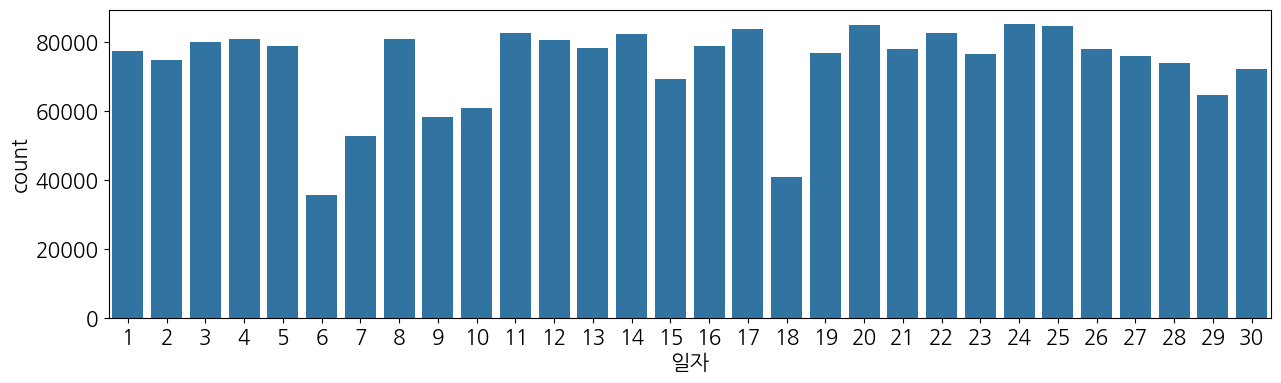

In [94]:
# 일자별 따릉이 이용건수 그래프 그리기
plt.figure(figsize=(15,4))
sns.countplot(data=bikes, x='일자')
plt.show()

6일과 18일에 유독 대여량이 적음

In [103]:
요일

['월', '화', '수', '목', '금', '토', '일']

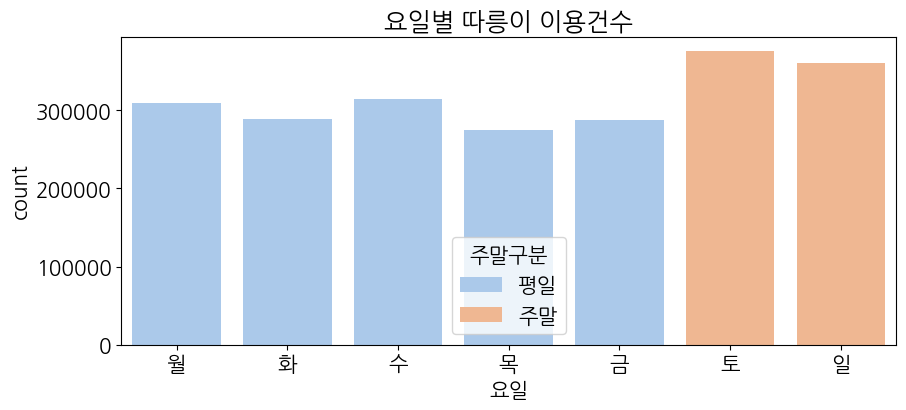

In [111]:
#요일별 따릉이 이용건수 그래프 그리기
plt.figure(figsize=(10,4))
sns.countplot(data=bikes, x='요일',hue='주말구분', order=요일, palette='pastel')
plt.title('요일별 따릉이 이용건수')
plt.show()

평일중에서는 목요일의 대여량이 적고, 주말은 대여량이 비교적 많음

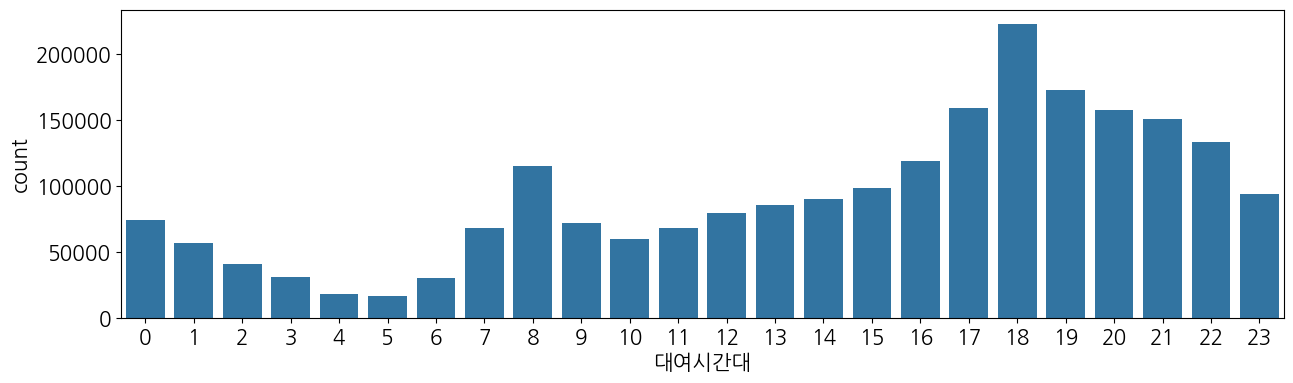

In [97]:
# 대여시간대별 따릉이 이용건수 그래프 그리기

plt.figure(figsize=(15,4))
sns.countplot(data=bikes, x='대여시간대')
plt.show()

In [118]:
# 두가지 요인을 위해 피봇 테이블 생성하기: 대여시간대 X 요일별 자전거 이용건수
# hourly_dayofweek_ride에 저장
hourly_dayofweek_ride = bikes.pivot_table(index='대여시간대', columns='요일', values='자전거번호', aggfunc='count')
hourly_dayofweek_ride[요일]


요일,월,화,수,목,금,토,일
대여시간대,,,,,,,
0,7461,9907,8624,9568,8353,13438,17025
1,4846,7529,7226,7508,6748,11232,11731
2,3305,4497,5328,5857,4762,8348,8804
3,2102,3157,3430,3992,3045,6221,8748
4,1544,1971,2160,2402,1979,3584,4076
5,2069,2316,2495,2451,2070,2619,2567
6,4455,4633,5393,4534,4252,3345,3311
7,11418,12070,13853,11324,10337,4869,4420
8,18762,22119,23542,17867,17164,8696,6651


In [ ]:
pd.Categorical(bikes['요일'], categories=요일, ordered=True) # 이 방법도 가능

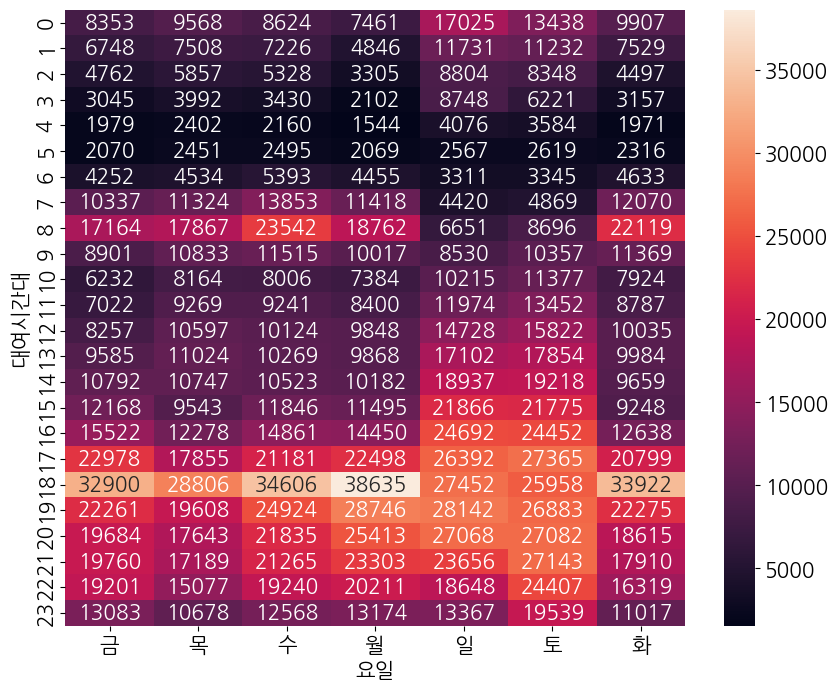

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data=hourly_dayofweek_ride, annot=True, fmt='d')
# annot- 정수로 표현해줌, fmt= format
plt.show()

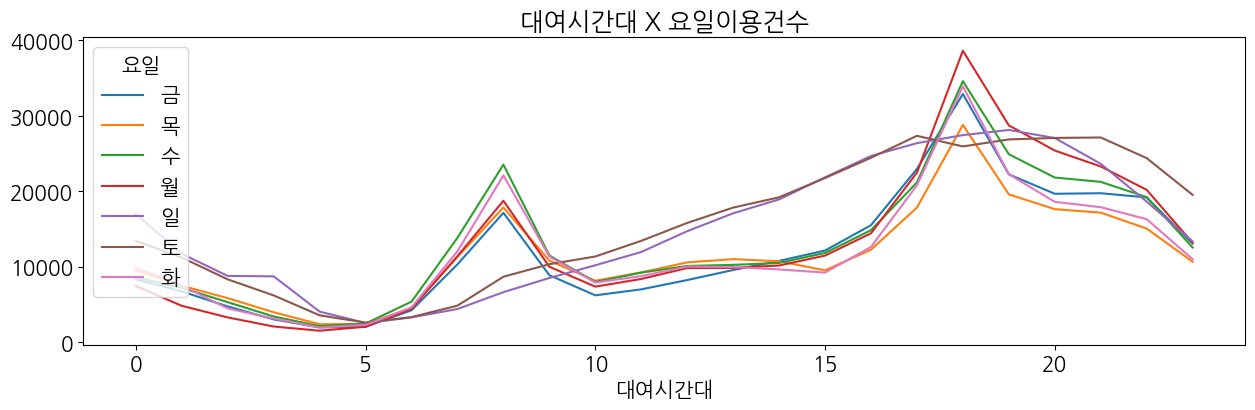

In [ ]:
# hourly_dayofweek_ride를 이용하여 대여시간대 X 요일이용건수 선그래프 그리기


<Axes: title={'center': '대여시간대 X 요일이용건수'}, xlabel='대여시간대'>

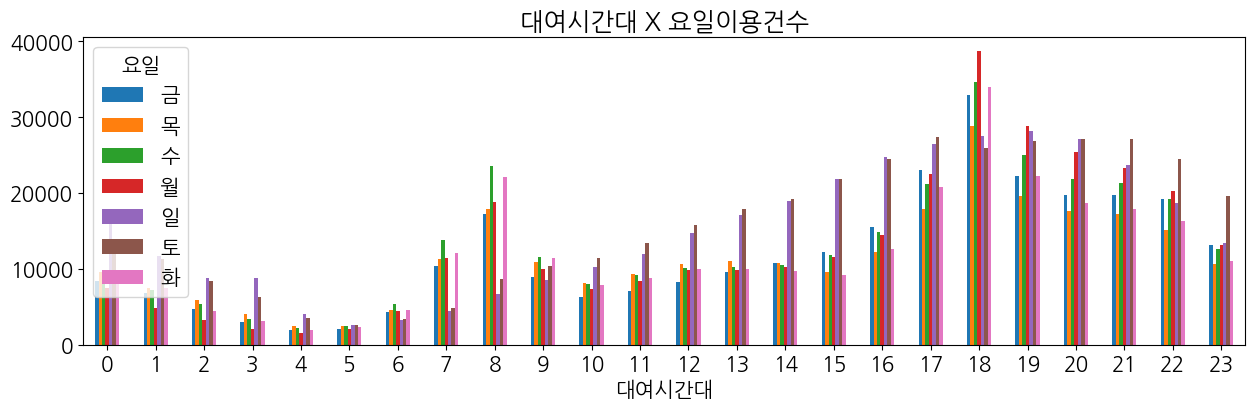

In [ ]:
# hourly_dayofweek_ride를 이용하여 대여시간대 X 요일이용건수 막대대그래프 그리기


In [ ]:
### sns.countplot() 사용하기

<Axes: xlabel='대여시간대', ylabel='count'>

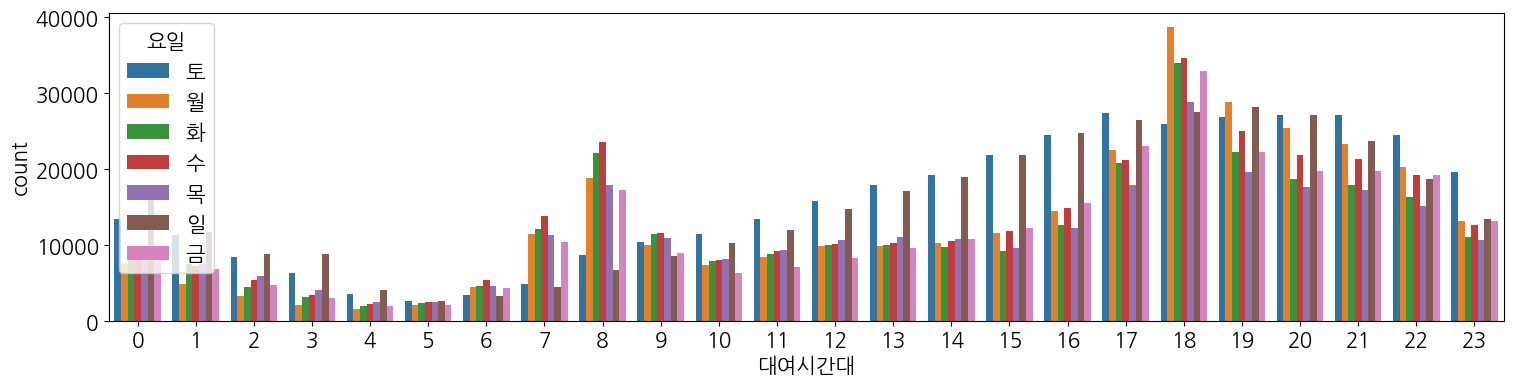

In [ ]:
# sns.countplot()를 이용하여 대여시간대 X 요일이용건수 막대그래프 그리기

plt.figure(figsize=(18,4))


<Axes: xlabel='요일', ylabel='대여시간대'>

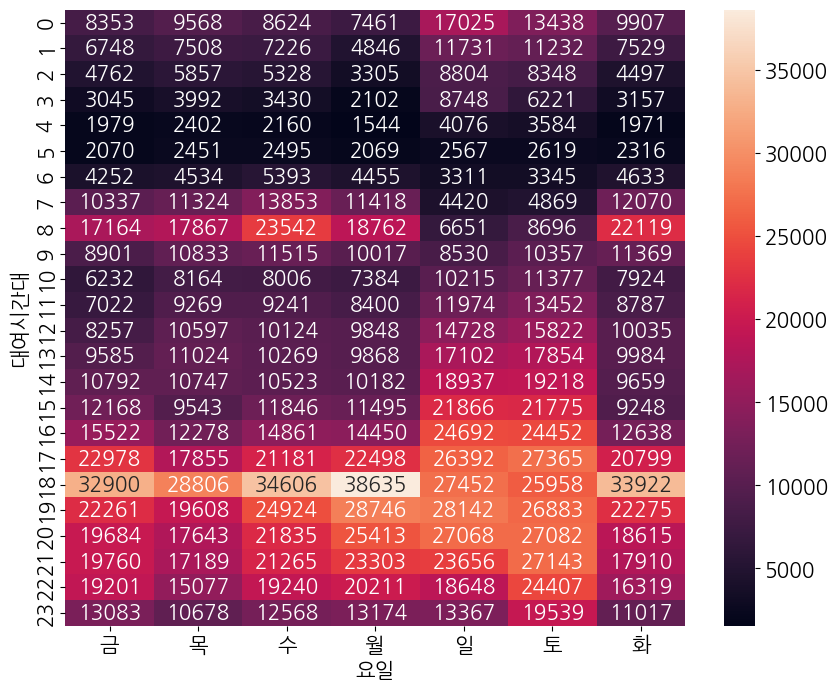

In [ ]:
# sns의 대여시간대 X 요일이용건수 히트맵그래프 그리기

plt.figure(figsize=(10,8))


## 6. 주말 구분 시각화 

In [123]:
## 주말 구분이 들어간 피봇 테이블 설정하기 weekdays_hourly_ride
weekdays_hourly_ride = bikes.pivot_table(index='대여시간대', columns='주말구분', values='자전거번호', aggfunc='count')
weekdays_hourly_ride

주말구분,주말,평일
대여시간대,,
0,30463,43913
1,22963,33857
2,17152,23749
3,14969,15726
4,7660,10056
5,5186,11401
6,6656,23267
7,9289,59002
8,15347,99454


<Axes: title={'center': '대여시간대 X 주말이용건수'}, xlabel='대여시간대'>

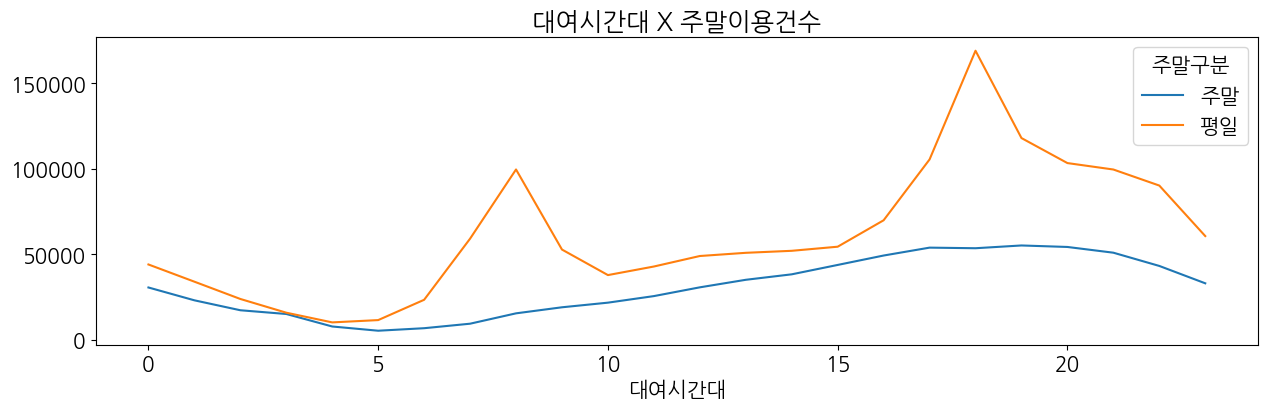

In [ ]:
# weekdays_hourly_ride를 이용하여 대여시간대 X 주말이용건수 선그래프 그리기


<Axes: title={'center': '대여시간대 X 주말이용건수'}, xlabel='대여시간대'>

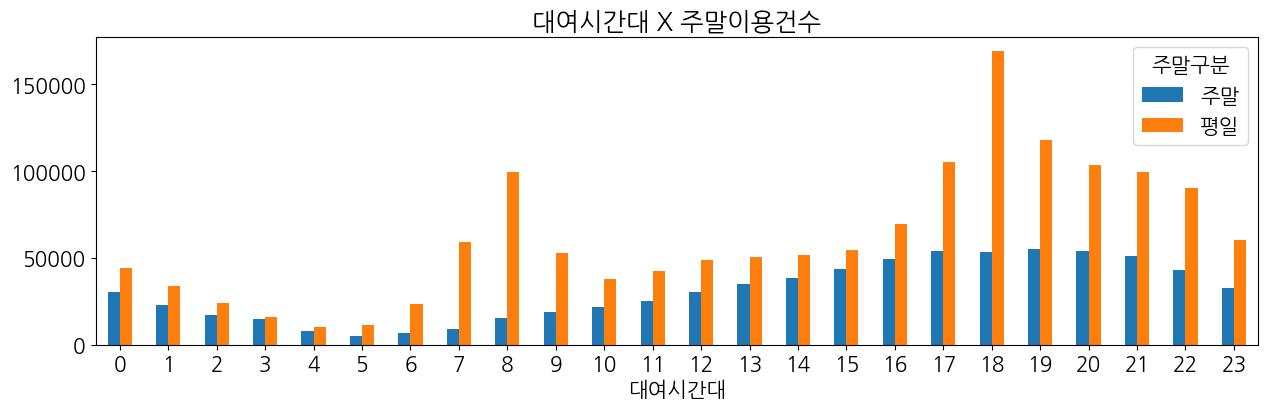

In [ ]:
# weekdays_hourly_ride를 이용하여 대여시간대 X 주말이용건수 막대그래프 그리기


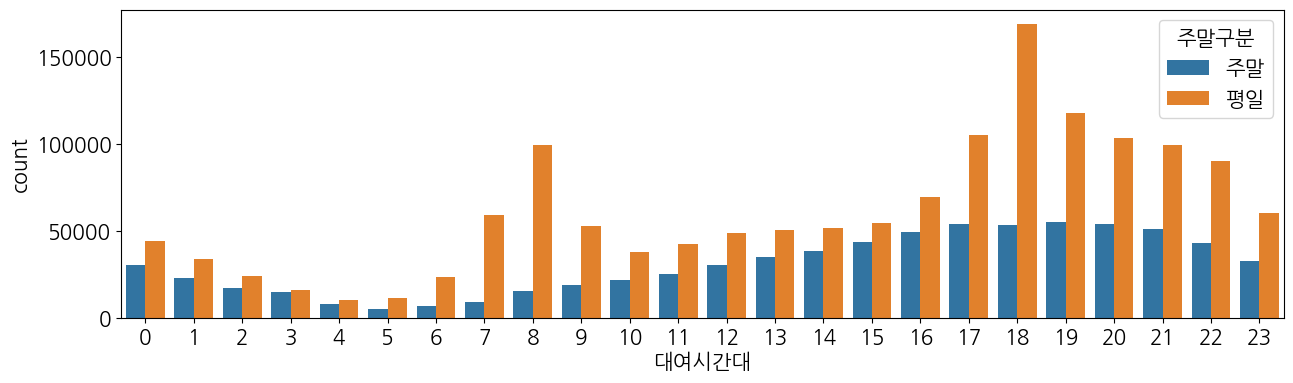

In [ ]:
# sns.countplot을 이용하여 대여시간대 X 주말이용건수 선그래프 그리기

plt.figure(figsize=(15, 4))


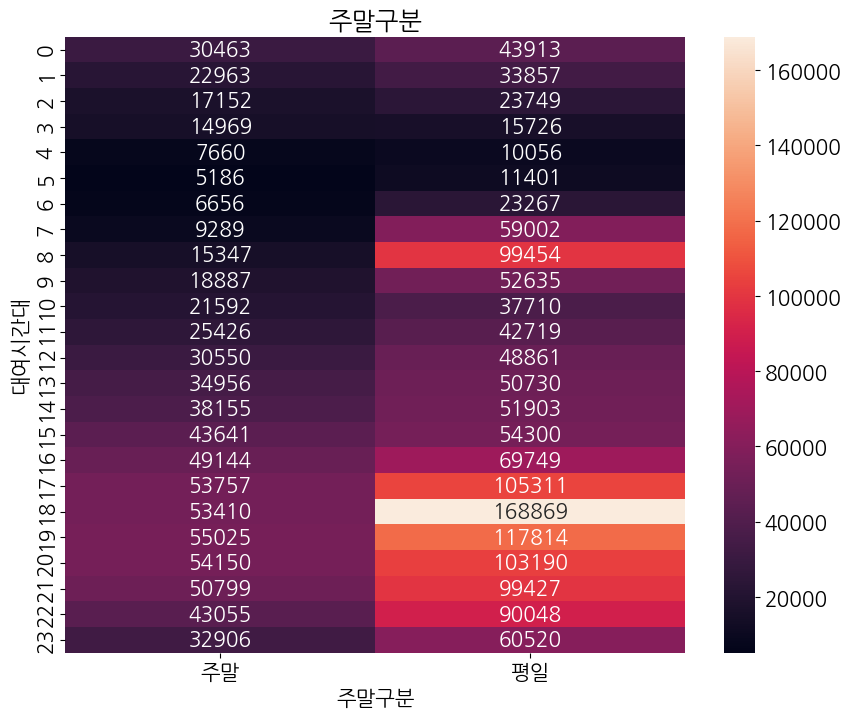

In [125]:
# sns를 이용하여 대여시간대 X 주말이용건수 히트맵 그리기

plt.figure(figsize=(10,8))
sns.heatmap(data=weekdays_hourly_ride, annot=True, fmt='d')
plt.title('주말구분')
plt.show()

## 7. 장소에 따른 시각화 folium

In [153]:
# 대여구별 이용건수 피봇테이블 만들기, 구별자전거이용건수

구별자전거이용건수 = bikes.pivot_table(
    index='대여구',
    columns='자전거번호',
    values='자전거번호',  # 집계 대상
    aggfunc='count',     # 개수 세기
)

구별자전거이용건수

ValueError: Grouper for '자전거번호' not 1-dimensional

In [ ]:
# 구별자전거이용건수 데이터프레임을 이용건수를 기준으로 오름차순으로 정렬하기


구별자전거이용건수

,자전거번호
대여구,
금천구,33488
도봉구,38697
강북구,40563
용산구,47993
중구,48533
동작구,54094
중랑구,56413
은평구,62996
양천구,64154


<Axes: title={'center': '대여구별 자전거 이용건수'}, ylabel='대여구'>

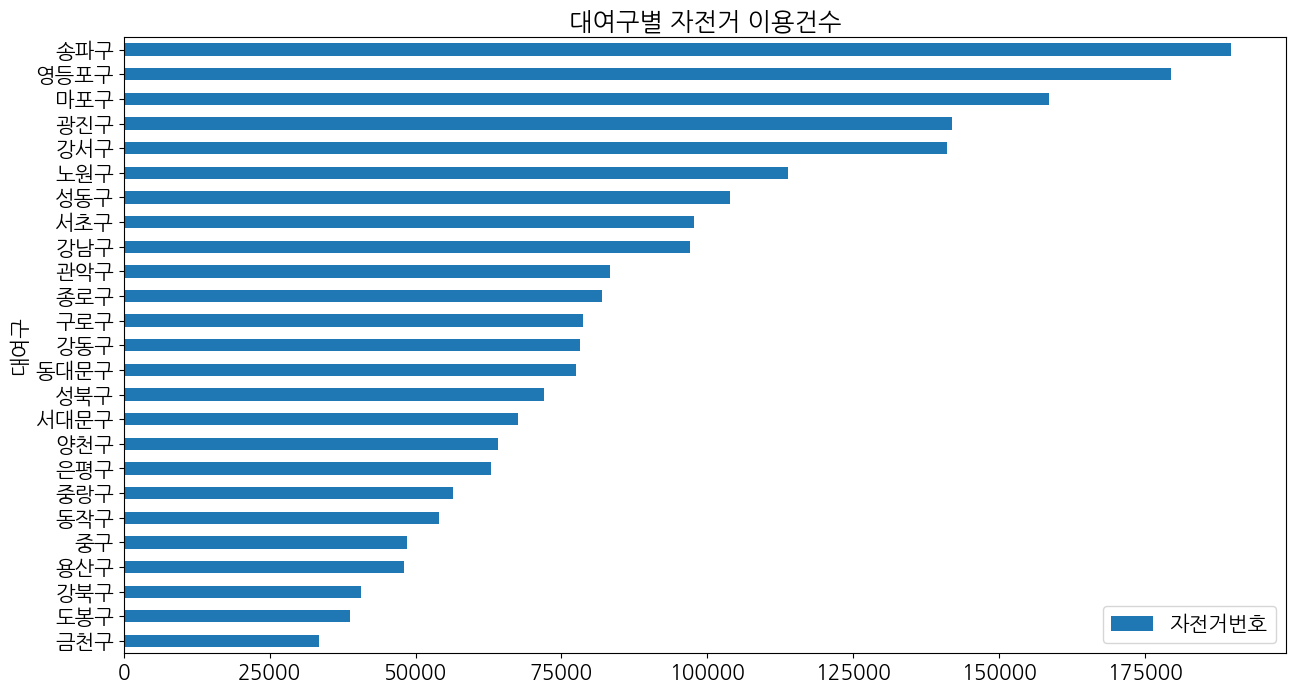

In [ ]:
# 구별자전거이용건수 수평막대그래프 그리기


In [ ]:
# 구별자전거이용건수 인덱스 번호 초기화하기기

구별자전거이용건수.head(2)

,대여구,자전거번호
0,금천구,33488
1,도봉구,38697


In [128]:
# 서울시 지도파일 정보 로드하기기

import json
with open('data/seoul.json','r', encoding='utf-8') as f:
    서울시지도 = json.load(f)

In [129]:
서울시지도

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.11540412678968, 37.557491025257455],
      [127.1165206546129, 37.557268061772696],
      [127.1175954493625, 37.55705301284316],
      [127.11879551821994, 37.557222485451305],
      [127.11969651045837, 37.558176474822524],
      [127.12057912633198, 37.5590144597372],
      [127.12146867175024, 37.55986003393365],
      [127.12240146859469, 37.5604208685133],
      [127.12287911525227, 37.56070873375976],
      [127.12303576608339, 37.56078573052513],
      [127.12435254630417, 37.56144246249796],
      [127.12447748580927, 37.56148569898355],
      [127.13349006006634, 37.56465664804646],
      [127.13357625665371, 37.56468978043648],
      [127.1336638698021, 37.56472375596808],
      [127.133755022522

In [136]:
# 지도에 나타내기 위해 대여점 위도와 대여점 경도의 평균값 구하기

lat = bikes['위도'].mean()
lon = bikes['경도'].mean()
print(lat, lon)

37.547349884422054 126.99171375923994


In [137]:
import folium

In [138]:
# 지도에 위치 표시하기 folium.Map() 함수 이용

map1 = folium.Map(location=(lat, lon), zoom_start=11)
map1

In [140]:
# 지도위에 구별자전거 이용건수 시각화하기 folium.Choropleth() 사용

folium.Choropleth(geo_data=서울시지도, data=구별자전거이용건수,
                columns=['대여구', '자전거번호'], 
                key_on='feature.properties.name').add_to(map1)
map1


NameError: name '구별자전거이용건수' is not defined

In [ ]:
## 미션: 구별이용시간평균 지도에 나타내기 ##

In [ ]:
# 대여구별 이용시간평균 (이용시간)
# 1단계 : 피봇 테이블 만들기

구별이용시간평균 = 
구별이용시간평균

,이용시간
대여구,
강남구,31.79
강동구,25.39
강북구,23.57
강서구,23.14
관악구,26.51
광진구,24.95
구로구,26.48
금천구,26.40
노원구,24.26


In [ ]:
#이용시간 컬럼을 기준으로 오름차순 정렬

구별이용시간평균

,이용시간
대여구,
강서구,23.14
성북구,23.17
종로구,23.32
강북구,23.57
동대문구,23.78
중랑구,24.24
노원구,24.26
광진구,24.95
도봉구,24.99


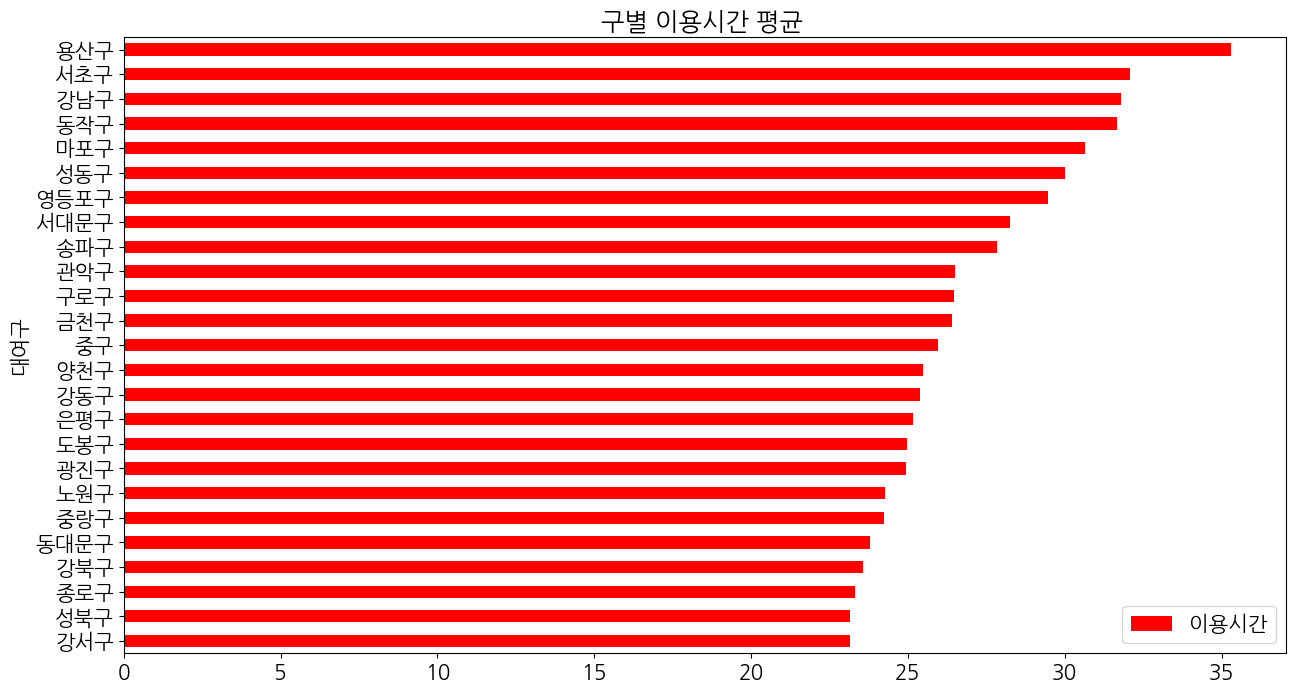

In [ ]:
# 구별 이용시간 평균 reset_index


구별이용시간평균

,대여구,이용시간
0,강서구,23.14
1,성북구,23.17
2,종로구,23.32
3,강북구,23.57
4,동대문구,23.78
5,중랑구,24.24
6,노원구,24.26
7,광진구,24.95
8,도봉구,24.99
9,은평구,25.16


In [ ]:
#지도 표시하기

map2


In [ ]:
#구별이용기간 평균에 사용하여 지도를 시각화

map2

## 8 . 시간적 X 장소적

In [ ]:
# pivot_table로 대여일자X 대여구별 따릉이 이용건수 계산하기, daily_gu_use

daily_gu_use = 
daily_gu_use

대여구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
일자,,,,,,,,,,,,,,,,,,,,,
1,3227,2774,1460,4476,3030,5215,2604,934,4015,1366,...,3505,2516,7206,2229,6327,1879,2286,2688,1561,1977
2,3071,2582,1518,4250,3198,5102,2526,916,3943,1351,...,3628,2444,6545,2056,6270,1883,2184,2463,1387,1807
3,3873,2734,1398,4987,3033,5290,2879,1340,4097,1414,...,3676,2620,6233,2186,6813,1663,2170,3090,1837,2047
4,3601,2820,1414,5120,3030,5213,2981,1281,4451,1441,...,3998,2728,6587,2364,6483,1543,2182,2896,1836,2082
5,3303,2735,1442,5280,3036,4879,2829,1294,4341,1385,...,3672,2573,6501,2278,6296,1595,2176,3120,1939,2113
6,1449,1371,743,2125,1448,2298,1282,456,2101,729,...,1659,1360,3050,1005,2566,739,1147,1209,669,1096
7,2458,1878,899,3320,1959,3201,1870,674,2746,880,...,2481,1733,4676,1551,4388,1148,1536,1994,1090,1218
8,3345,2978,1540,4712,3343,5437,2787,953,4159,1493,...,3629,2623,7369,2372,6859,1927,2370,2573,1472,2084
9,2380,2194,1216,3354,2561,3772,1922,661,3134,1120,...,2719,2088,5236,1706,4538,1316,1668,2069,1126,1514


<Axes: xlabel='대여구', ylabel='일자'>

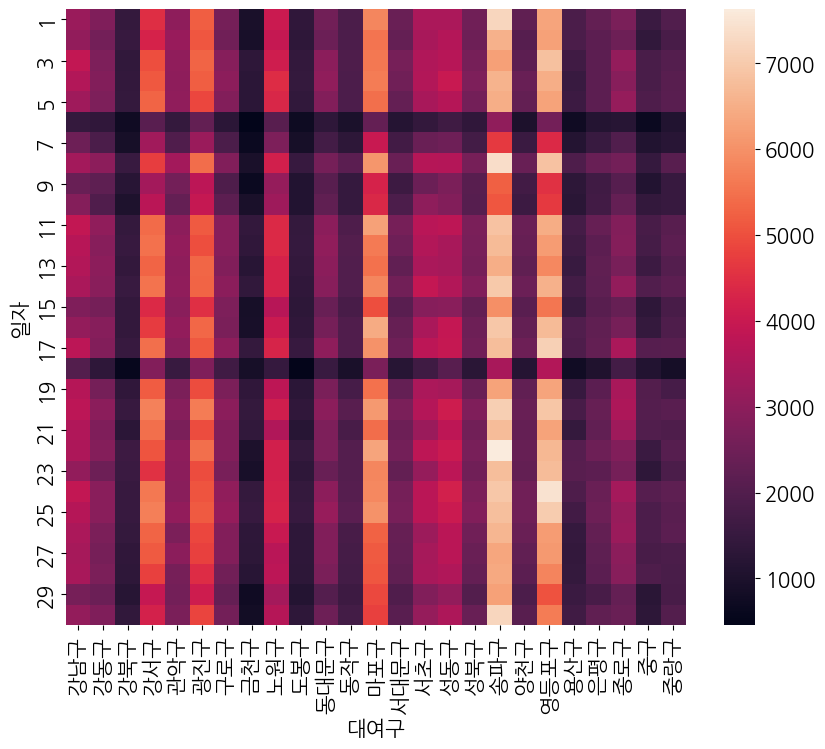

In [ ]:
# 대여일자X 대여구별 따릉이 이용건수 히트맵으로 표시하기기

plt.figure(figsize=(10,8))


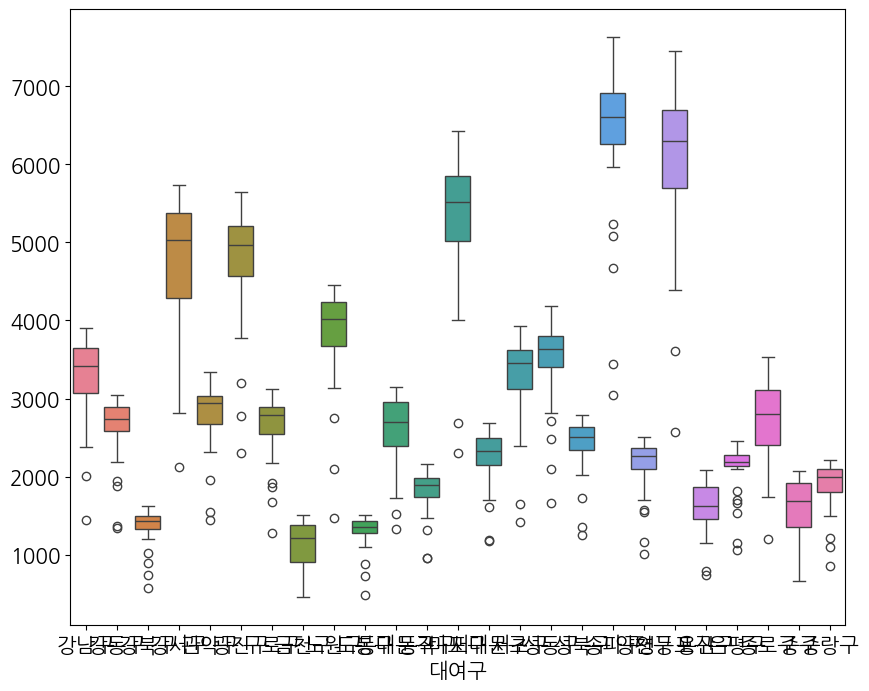

In [ ]:
# 대여일자X 대여구별 따릉이 이용건수 박스플롯으로 그리기

plt.figure(figsize=(10,8))


In [ ]:
## 미션: 대여시간대별 ##

In [ ]:
## 대여시간대 X 대여구 따릉이 이용건수 계산하기

hourly_gu_use = 
hourly_gu_use

대여구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
대여시간대,,,,,,,,,,,,,,,,,,,,,
0,2643,3230,2066,4459,3769,5314,2650,790,4855,1529,...,3003,3165,6014,2091,4892,1641,2389,1697,1180,2369
1,2660,2342,1706,3306,2830,3621,1797,650,3632,1297,...,2096,2501,5150,1770,3314,1334,1873,1299,893,1944
2,2360,1852,1378,2442,1899,2469,1291,496,2610,853,...,1394,1941,3339,1143,2190,935,1330,978,683,1413
3,1689,1398,932,1909,1550,1830,853,328,1932,668,...,1103,1337,2390,859,1627,755,977,749,564,1171
4,920,620,595,1152,990,998,572,173,1052,403,...,743,701,1252,479,1109,512,508,552,407,580
5,648,686,392,1072,745,992,543,161,829,416,...,698,522,1086,565,1140,305,527,741,442,597
6,1316,1173,499,2144,1042,1687,1081,511,1413,498,...,1092,1089,2326,988,2682,541,1025,1079,538,826
7,2404,2420,1047,4854,2800,3512,3091,1623,2841,1120,...,2588,2297,5214,2674,6516,1094,2430,2664,1259,2128
8,4951,3728,1533,9357,4350,6988,4691,3337,4491,1541,...,5446,3763,9105,3886,9939,1866,3420,4317,2262,3061


<Axes: xlabel='대여시간대', ylabel='대여구'>

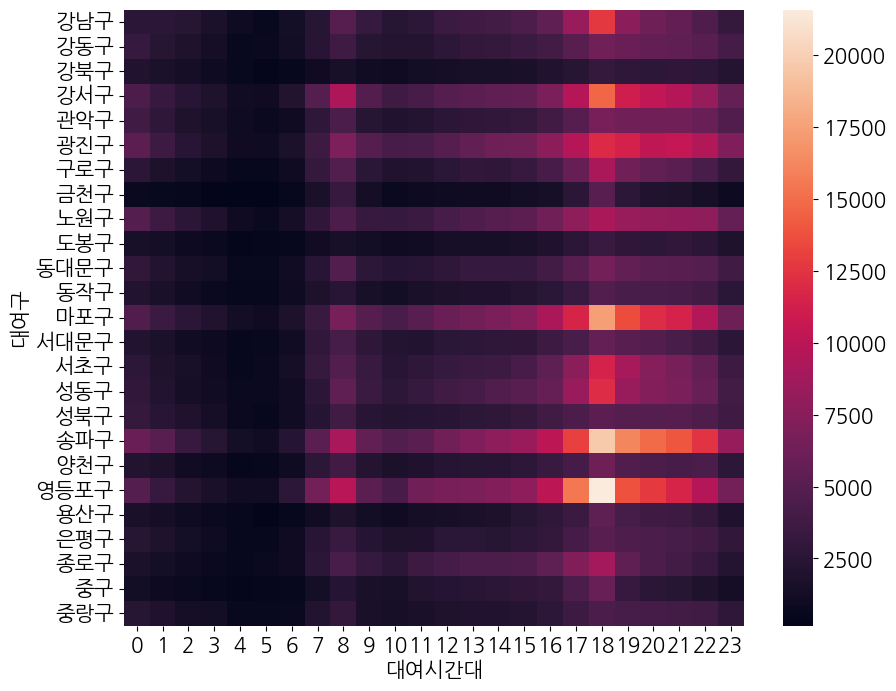

In [ ]:
#히트맵
plt.figure(figsize=(10,8))

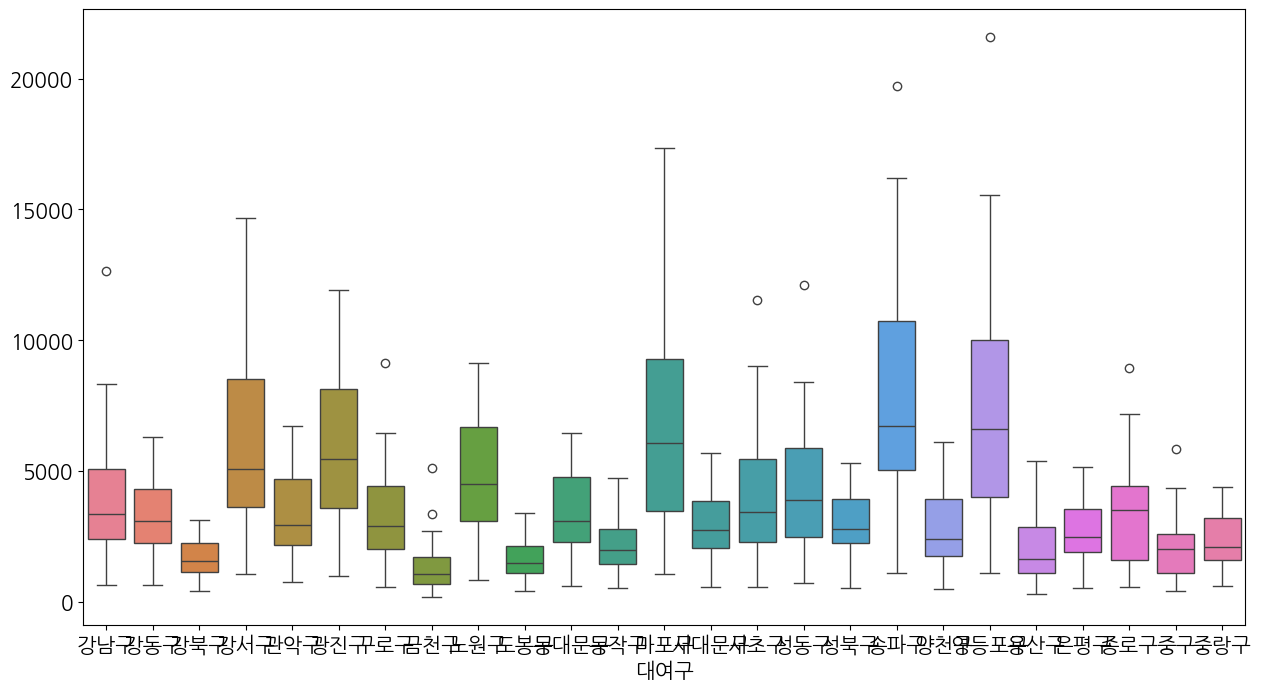

In [ ]:
# 박스 그래프로 표기
plt.figure(figsize=(15,8))

## 9. TOP 50


In [ ]:
# 미션: 서울시에서 주말에 인기있는 TOP 대여소 지도에 표시하기
# 미션: 서울시에서 평일일에 인기있는 TOP 대여소 지도에 표시하기

In [ ]:
## 대여 대여소  X 주말 구분 이용건수 계산을 위한 피벗 테이블



,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
(구)신한은행 중랑교지점,37.60,127.08,391,832
(구)합정동 주민센터,37.55,126.91,357,715
3호선 매봉역 3번출구앞,37.49,127.05,443,1049
419민주묘지역,37.65,127.01,547,946
8삼호@ 2동 ( 간선도로),37.49,127.05,111,316
...,...,...,...,...
휘봉고등학교 앞,37.59,127.07,193,370
흑석역 1번출구,37.51,126.96,1297,2195
흑석역 4번출구,37.51,126.96,184,412


In [ ]:
# 대여 대여소  X 주말 구분 이용건수 계산을 위한 피벗 테이블 만들기 
# '대여 대여소명','대여점위도','대여점경도'

rent_bikes = 
rent_bikes

,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
(구)신한은행 중랑교지점,37.60,127.08,391,832
(구)합정동 주민센터,37.55,126.91,357,715
3호선 매봉역 3번출구앞,37.49,127.05,443,1049
419민주묘지역,37.65,127.01,547,946
8삼호@ 2동 ( 간선도로),37.49,127.05,111,316
...,...,...,...,...
휘봉고등학교 앞,37.59,127.07,193,370
흑석역 1번출구,37.51,126.96,1297,2195
흑석역 4번출구,37.51,126.96,184,412


In [ ]:
# 인기있는 주말 대여점 50개를 구하기


,,주말구분,주말,평일
대여 대여소명,대여점위도,대여점경도,,
뚝섬유원지역 1번출구 앞,37.53,127.07,5777,6840
여의나루역 1번출구 앞,37.53,126.93,5286,6241
"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932,4556
봉림교 교통섬,37.48,126.93,3699,5986
롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231,5383
마포구민체육센터 앞,37.56,126.90,3229,3893
건대입구역 사거리(롯데백화점),37.54,127.07,3169,4573
홍대입구역 2번출구 앞,37.56,126.92,2922,5617
잠실새내역 5번 출구 뒤,37.51,127.09,2632,3660


In [ ]:
# 인기있는 주말 대여점 50개중 '주말' 컬럼만 추출


대여 대여소명                  대여점위도  대여점경도 
뚝섬유원지역 1번출구 앞            37.53  127.07    5777
여의나루역 1번출구 앞             37.53  126.93    5286
고속터미널역 8-1번, 8-2번 출구 사이  37.51  127.00    3932
봉림교 교통섬                  37.48  126.93    3699
롯데월드타워(잠실역2번출구 쪽)        37.51  127.10    3231
마포구민체육센터 앞               37.56  126.90    3229
건대입구역 사거리(롯데백화점)         37.54  127.07    3169
홍대입구역 2번출구 앞             37.56  126.92    2922
잠실새내역 5번 출구 뒤            37.51  127.09    2632
당산육갑문                    37.54  126.90    2327
신도림역 1번 출구 앞             37.51  126.89    2304
IFC몰                     37.53  126.93    2240
합정역 7번출구 앞               37.55  126.91    2194
동방1교                     37.47  126.93    2170
서울숲 관리사무소                37.54  127.04    2141
안암로터리 버스정류장 앞            37.58  127.03    2058
올림픽공원역 3번출구              37.52  127.13    2011
CJ 드림시티                  37.60  126.92    2002
당산역 10번출구 앞              37.53  126.90    1978
노들역 1번출구                 37.51  126.95    1905
신대방역 2번 출구           

In [ ]:
# 인기있는 주말 대여점 50개중 '주말' 컬럼만 추출하여 주말대여점50에 저장장

주말대여점50 = 
주말대여점50

,대여 대여소명,대여점위도,대여점경도,주말
0,뚝섬유원지역 1번출구 앞,37.53,127.07,5777
1,여의나루역 1번출구 앞,37.53,126.93,5286
2,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932
3,봉림교 교통섬,37.48,126.93,3699
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231
5,마포구민체육센터 앞,37.56,126.90,3229
6,건대입구역 사거리(롯데백화점),37.54,127.07,3169
7,홍대입구역 2번출구 앞,37.56,126.92,2922
8,잠실새내역 5번 출구 뒤,37.51,127.09,2632
9,당산육갑문,37.54,126.90,2327


In [ ]:
# 평일대여점 데이터 프레임 만들기기
평일대여점50 = 
평일대여점50

,대여 대여소명,대여점위도,대여점경도,평일
0,뚝섬유원지역 1번출구 앞,37.53,127.07,6840
1,여의나루역 1번출구 앞,37.53,126.93,6241
2,봉림교 교통섬,37.48,126.93,5986
3,홍대입구역 2번출구 앞,37.56,126.92,5617
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,5383
5,마곡나루역 5번출구 뒤편,37.57,126.83,4648
6,건대입구역 사거리(롯데백화점),37.54,127.07,4573
7,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,4556
8,양천향교역 7번출구앞,37.57,126.84,4342
9,안암로터리 버스정류장 앞,37.58,127.03,4127


In [ ]:
## 주말 대여점50의 가운데 지점의 위도 경도 중심으로 초기 map 그리기

map3


In [ ]:
주말대여점50.head(10)


,대여 대여소명,대여점위도,대여점경도,주말
0,뚝섬유원지역 1번출구 앞,37.53,127.07,5777
1,여의나루역 1번출구 앞,37.53,126.93,5286
2,"고속터미널역 8-1번, 8-2번 출구 사이",37.51,127.00,3932
3,봉림교 교통섬,37.48,126.93,3699
4,롯데월드타워(잠실역2번출구 쪽),37.51,127.10,3231
5,마포구민체육센터 앞,37.56,126.90,3229
6,건대입구역 사거리(롯데백화점),37.54,127.07,3169
7,홍대입구역 2번출구 앞,37.56,126.92,2922
8,잠실새내역 5번 출구 뒤,37.51,127.09,2632
9,당산육갑문,37.54,126.90,2327


In [ ]:
# for문을 사용해서 주말 대여점 50지도를 시각화하기


map3


In [ ]:
## 평일 대여점 이용이 많은 대여소를 표시


map3

In [ ]:
# 시각화데이터를 통해 정보 및 인사이트 도출하기!!!!